In [1]:
import sys
sys.path.append('/home/barluz/Analisis Numerico/Ch2-Ecuaciones-1-variable')

## Problema 1 – Punto fijo y raíz de $f(x)=x^4+2x^2-x-3$

Demostrar que cada una de las siguientes funciones tiene un punto fijo en $p$ **si y solo si** $f(p)=0$.

### a) $g_1(x) = (3 + x - 2x^2)^{1/4}$

\[
\begin{aligned}
p = g_1(p) &\iff p^4 = 3 + p - 2p^2 \\
           &\iff p^4 + 2p^2 - p - 3 = 0 \\
           &\iff f(p)=0.
\end{aligned}
\]

### b) $g_2(x) = \left(\frac{x + 3 - x^4}{2}\right)^{1/2}$

\[
\begin{aligned}
p = g_2(p) &\iff p^2 = \frac{p + 3 - p^4}{2} \\
           &\iff 2p^2 = p + 3 - p^4 \\
           &\iff p^4 + 2p^2 - p - 3 = 0 \\
           &\iff f(p)=0.
\end{aligned}
\]

### c) $g_3(x) = \left(\frac{x + 3}{x^2 + 2}\right)^{1/2}$

\[
\begin{aligned}
p = g_3(p) &\iff p^2 = \frac{p+3}{p^2+2} \\
           &\iff p^2(p^2+2) = p+3 \\
           &\iff p^4 + 2p^2 - p - 3 = 0 \\
           &\iff f(p)=0.
\end{aligned}
\]

### d) $g_4(x) = \frac{3x^4 + 2x^2 + 3}{4x^3 + 4x - 1}$

\[
\begin{aligned}
p = g_4(p) &\iff p(4p^3+4p-1) = 3p^4+2p^2+3 \\
           &\iff 4p^4+4p^2-p = 3p^4+2p^2+3 \\
           &\iff p^4+2p^2-p-3 = 0 \\
           &\iff f(p)=0.
\end{aligned}
\]

Por lo tanto, en todos los casos $p$ es punto fijo de $g_i$ exactamente cuando $p$ es raíz de $f$.

In [3]:
import math
from scipy.optimize import bisect

def f(x):
    return x**4 + 2*x**2 - x - 3

def g1(x):
    return (3 + x - 2*x**2)**0.25

def g2(x):
    return ((x + 3 - x**4)/2)**0.5

def g3(x):
    return ((x + 3)/(x**2 + 2))**0.5

def g4(x):
    return (3*x**4 + 2*x**2 + 3) / (4*x**3 + 4*x - 1)

# Buscar una raíz real en [1,2] (f(1)=-1, f(2)=19)
p = bisect(f, 1, 1.5)
print(f"Raíz de f: p = {p:.10f}")
print(f"f(p) = {f(p):.2e}")
print(f"g1(p) = {g1(p):.10f}")
print(f"g2(p) = {g2(p):.10f}")
print(f"g3(p) = {g3(p):.10f}")
print(f"g4(p) = {g4(p):.10f}")

Raíz de f: p = 1.1241230297
f(p) = -5.68e-12
g1(p) = 1.1241230297
g2(p) = 1.1241230297
g3(p) = 1.1241230297
g4(p) = 1.1241230297


## Problema 3 – Punto fijo para $f(x)=x^3-2x+1=0$

Se proponen cuatro métodos de punto fijo a partir de $f(x)=0$. Para cada uno, derivamos la función $g$ y calculamos las primeras cuatro iteraciones con $p_0 = 0.5$.

### a) $x = \frac{1}{2}(x^3 + 1)$

Despejando de $x^3 - 2x + 1 = 0$:

\[
x^3 + 1 = 2x \quad\Rightarrow\quad x = \frac{x^3 + 1}{2}
\]

Por tanto $g_a(x) = \frac{1}{2}(x^3 + 1)$.

### b) $x = \frac{2}{x} - \frac{1}{x^2}$

Reescribiendo $x^3 - 2x + 1 = 0$ como $x^3 = 2x - 1$. Dividiendo por $x^2$ (para $x \neq 0$):

\[
x = \frac{2}{x} - \frac{1}{x^2}
\]

Así $g_b(x) = \frac{2}{x} - \frac{1}{x^2}$.

### c) $x = \sqrt{2 - \frac{1}{x}}$

De $x^3 = 2x - 1$, despejamos $x^2$? Otra forma: $x^2 = 2 - \frac{1}{x}$, siempre que $x>0$. Entonces

\[
x = \sqrt{2 - \frac{1}{x}}
\]

Luego $g_c(x) = \sqrt{2 - \frac{1}{x}}$ (raíz principal positiva).

### d) $x = -\sqrt[3]{1 - 2x}$

De $x^3 = 2x - 1$, despejamos $x^3 = -(1 - 2x)$, luego

\[
x = -\sqrt[3]{1 - 2x}
\]

Por tanto $g_d(x) = -\sqrt[3]{1 - 2x}$.

In [4]:
import math

# Definir las funciones g
def g_a(x):
    return 0.5 * (x**3 + 1)

def g_b(x):
    return 2/x - 1/x**2

def g_c(x):
    return math.sqrt(2 - 1/x)

def g_d(x):
    return - (1 - 2*x)**(1/3)

# Iteración general
def iterar(g, p0, n=4):
    resultados = [p0]
    for i in range(n):
        try:
            p_next = g(resultados[-1])
            resultados.append(p_next)
        except Exception as e:
            resultados.append(f"Error: {e}")
            break
    return resultados

# Aplicar a cada método
p0 = 0.5
metodos = {
    "a) g_a(x) = (x³+1)/2": g_a,
    "b) g_b(x) = 2/x - 1/x²": g_b,
    "c) g_c(x) = √(2 - 1/x)": g_c,
    "d) g_d(x) = -∛(1-2x)": g_d
}

print("Iteraciones desde p0 = 0.5\n")
for nombre, g in metodos.items():
    it = iterar(g, p0, 4)
    print(f"{nombre}:")
    for i, val in enumerate(it):
        print(f"  p{i} = {val}")
    print()

Iteraciones desde p0 = 0.5

a) g_a(x) = (x³+1)/2:
  p0 = 0.5
  p1 = 0.5625
  p2 = 0.5889892578125
  p3 = 0.602162644566306
  p4 = 0.6091720424515518

b) g_b(x) = 2/x - 1/x²:
  p0 = 0.5
  p1 = 0.0
  p2 = Error: division by zero

c) g_c(x) = √(2 - 1/x):
  p0 = 0.5
  p1 = 0.0
  p2 = Error: division by zero

d) g_d(x) = -∛(1-2x):
  p0 = 0.5
  p1 = -0.0
  p2 = -1.0
  p3 = -1.4422495703074083
  p4 = -1.5719727376444834



## Resultados numéricos

### Método a) $g_a(x) = (x^3+1)/2$

- $p_0 = 0.5$
- $p_1 = 0.5(0.125+1) = 0.5625$
- $p_2 = 0.5(0.1779785+1) = 0.58898925$
- $p_3 = 0.5(0.204306+1) = 0.602153$
- $p_4 = 0.5(0.218347+1) = 0.6091735$

La sucesión converge monótonamente a la raíz $r \approx 0.618034$. **Método apropiado**.

### Método b) $g_b(x) = \frac{2}{x} - \frac{1}{x^2}$

- $p_1 = 4 - 4 = 0$
- $p_2$ requiere división por $0$ → **indefinido**.

Falla inmediatamente. No es apropiado.

### Método c) $g_c(x) = \sqrt{2 - 1/x}$

- $p_1 = \sqrt{2 - 2} = 0$
- $p_2$ requiere $\sqrt{2 - 1/0}$ → **indefinido**.

También falla. No es apropiado.

### Método d) $g_d(x) = -\sqrt[3]{1 - 2x}$

- $p_1 = -\sqrt[3]{1-1} = 0$
- $p_2 = -\sqrt[3]{1-0} = -1$
- $p_3 = -\sqrt[3]{1-2(-1)} = -\sqrt[3]{3} \approx -1.44225$
- $p_4 = -\sqrt[3]{1-2(-1.44225)} = -\sqrt[3]{3.8845} \approx -1.57106$

La sucesión se aleja de la raíz positiva y parece converger a la raíz negativa $r \approx -1.618034$ (aunque lentamente). **No es apropiado** para encontrar la raíz cercana a $p_0=0.5$.

## Conclusión

Solo el **método a)** es apropiado para aproximar la raíz $x \approx 0.618034$ partiendo de $p_0 = 0.5$. Los otros métodos fallan por división por cero o convergen a otra raíz.

Iter 0: p0 = 1.0000000000
Iter 1: p1 = 1.5650845801
Iter   2: p = 1.7935728786, g(p) = 1.8859437430
Iter   3: p = 1.8859437430, g(p) = 1.9228478440
Iter   4: p = 1.9228478440, g(p) = 1.9375075400
Iter   5: p = 1.9375075400, g(p) = 1.9433169299
Iter   6: p = 1.9433169299, g(p) = 1.9456168565

--- Ejercicio 7 ---
Raíz aproximada: 1.94331693
Razón: Error absoluto 5.81e-03 < 1.00e-02
Iteraciones: 6


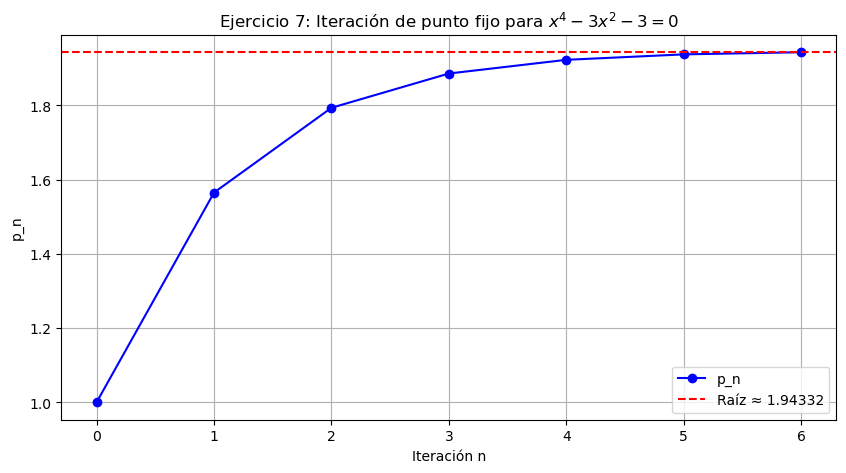

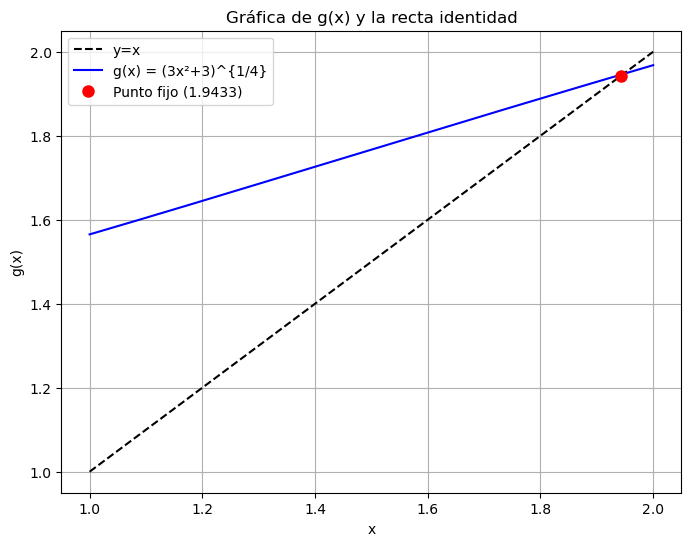

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from src.root_finding import punto_fijo

# Definir la función g
def g7(x):
    return (3*x*x + 3)**0.25

# Parámetros
p0 = 1.0
tol = 1e-2
max_iter = 20

# Aplicar punto fijo
raiz7, hist7, razon7 = punto_fijo(g7, p0, tol_abs=tol, rel_tol=None, max_iter=max_iter, verbose=True)

print(f"\n--- Ejercicio 7 ---")
print(f"Raíz aproximada: {raiz7:.8f}")
print(f"Razón: {razon7}")
print(f"Iteraciones: {len(hist7)-1}")

# Gráfica de la convergencia
iteraciones = [h[0] for h in hist7]
valores = [h[1] for h in hist7]

plt.figure(figsize=(10,5))
plt.plot(iteraciones, valores, 'bo-', label='p_n')
plt.axhline(raiz7, color='r', linestyle='--', label=f'Raíz ≈ {raiz7:.5f}')
plt.xlabel('Iteración n')
plt.ylabel('p_n')
plt.title('Ejercicio 7: Iteración de punto fijo para $x^4-3x^2-3=0$')
plt.legend()
plt.grid(True)
plt.show()

# También graficamos g(x) y la recta y=x para ver el punto fijo
x_vals = np.linspace(1, 2, 200)
g_vals = g7(x_vals)
plt.figure(figsize=(8,6))
plt.plot(x_vals, x_vals, 'k--', label='y=x')
plt.plot(x_vals, g_vals, 'b-', label='g(x) = (3x²+3)^{1/4}')
plt.plot(raiz7, raiz7, 'ro', markersize=8, label=f'Punto fijo ({raiz7:.4f})')
plt.xlabel('x')
plt.ylabel('g(x)')
plt.title('Gráfica de g(x) y la recta identidad')
plt.legend()
plt.grid(True)
plt.show()

Iter 0: p0 = 2.0000000000
Iter 1: p1 = 3.5623281460
Iter   2: p = 3.6305697477, g(p) = 3.6267232807
Iter   3: p = 3.6267232807, g(p) = 3.6269551524

--- Ejercicio 9 ---
Punto fijo aproximado: 3.62672328
Razón: Error absoluto 3.85e-03 < 1.00e-02
Iteraciones reales: 3
n teórico (corolario 2.5): 5
Comparación: teórico 5 vs real 3


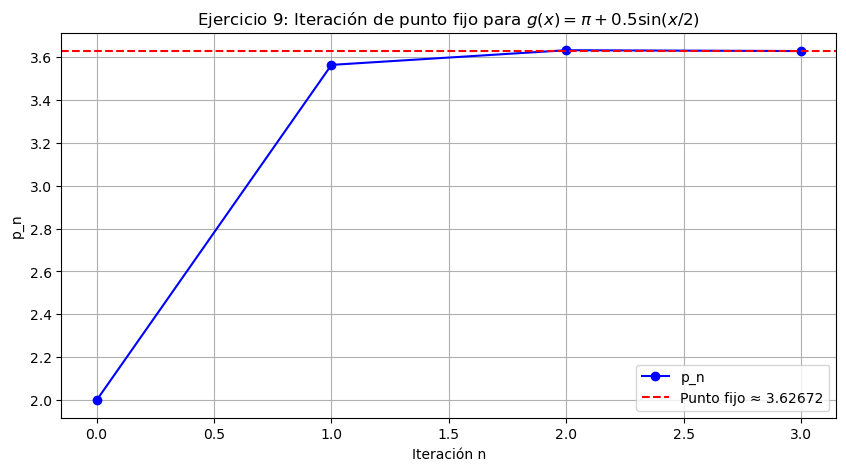

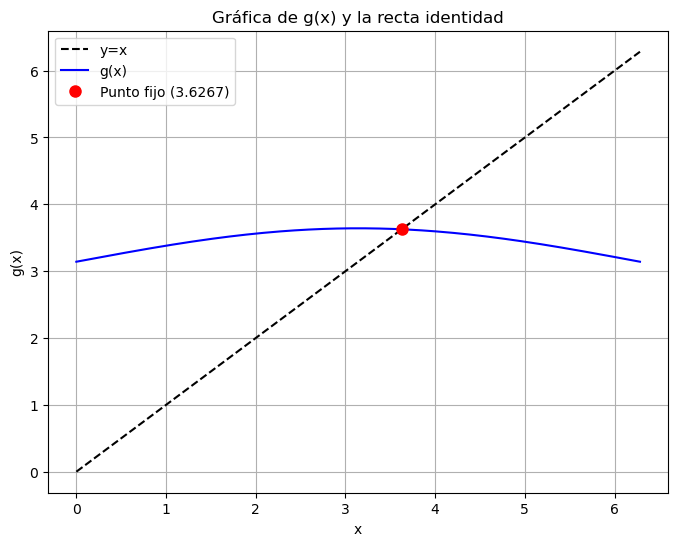

In [7]:
import math
import numpy as np
import matplotlib.pyplot as plt
from src.root_finding import punto_fijo

# Definir g(x) = π + 0.5 sen(x/2)
def g9(x):
    return math.pi + 0.5 * math.sin(x/2)

p0 = 2.0   # aproximación inicial (cualquiera dentro del intervalo funciona)
tol = 1e-2
max_iter = 20

# Aplicar punto fijo
raiz9, hist9, razon9 = punto_fijo(g9, p0, tol_abs=tol, rel_tol=None, max_iter=max_iter, verbose=True)

print(f"\n--- Ejercicio 9 ---")
print(f"Punto fijo aproximado: {raiz9:.8f}")
print(f"Razón: {razon9}")
iter_reales = len(hist9) - 1
print(f"Iteraciones reales: {iter_reales}")

# Cálculo teórico del número de iteraciones (corolario 2.5)
# La cota de error es |p_n - p| ≤ k^n * max(p0-a, b-p0)
# con k = max|g'(x)| = 0.25, intervalo [0, 2π], p0=2
k = 0.25
a, b = 0, 2*math.pi
max_inicial = max(p0 - a, b - p0)
# Queremos k^n * max_inicial < 1e-2 → 0.25^n * 4.283 < 0.01 → 0.25^n < 0.01/4.283 ≈ 0.002335
# n > log(0.002335)/log(0.25) ≈ log10(0.002335)/log10(0.25)
import math
n_teorico = math.ceil(math.log(0.01 / max_inicial) / math.log(k))
print(f"n teórico (corolario 2.5): {n_teorico}")
print(f"Comparación: teórico {n_teorico} vs real {iter_reales}")

# Gráfica de convergencia
iteraciones = [h[0] for h in hist9]
valores = [h[1] for h in hist9]
plt.figure(figsize=(10,5))
plt.plot(iteraciones, valores, 'bo-', label='p_n')
plt.axhline(raiz9, color='r', linestyle='--', label=f'Punto fijo ≈ {raiz9:.5f}')
plt.xlabel('Iteración n')
plt.ylabel('p_n')
plt.title('Ejercicio 9: Iteración de punto fijo para $g(x)=\\pi+0.5\\sin(x/2)$')
plt.legend()
plt.grid(True)
plt.show()

# Gráfica de g(x) y la recta y=x
x_vals = np.linspace(0, 2*math.pi, 200)
g_vals = [g9(x) for x in x_vals]
plt.figure(figsize=(8,6))
plt.plot(x_vals, x_vals, 'k--', label='y=x')
plt.plot(x_vals, g_vals, 'b-', label='g(x)')
plt.plot(raiz9, raiz9, 'ro', markersize=8, label=f'Punto fijo ({raiz9:.4f})')
plt.xlabel('x')
plt.ylabel('g(x)')
plt.title('Gráfica de g(x) y la recta identidad')
plt.legend()
plt.grid(True)
plt.show()

## Ejercicio 12 (sección 2.2): Aproximación de $\sqrt[3]{25}$ por punto fijo

Se pide encontrar una aproximación para $\sqrt[3]{25}$ con una precisión de $10^{-4}$ mediante iteración de punto fijo, y comparar el resultado y el número de iteraciones con los obtenidos en el ejercicio 13 de la sección 2.1 (donde se usó el método de bisección).

### 1. Elección de la función de iteración $g(x)$

La ecuación a resolver es $x^3 = 25$, o equivalentemente $f(x)=x^3-25=0$.  
Para aplicar el método de punto fijo, debemos reescribirla como $x = g(x)$. Hay varias formas posibles:

- $g_1(x) = \dfrac{25}{x^2}$  
- $g_2(x) = \sqrt{\dfrac{25}{x}} = \dfrac{5}{\sqrt{x}}$  
- $g_3(x) = \dfrac{2x + \dfrac{25}{x^2}}{3}$ (promedio ponderado que conduce al método de Newton)

Analicemos la convergencia. La derivada de $g$ en la raíz $p = \sqrt[3]{25} \approx 2.924017738$ determina la contractividad.

- $g_1'(x) = -\dfrac{50}{x^3}$ ⇒ $|g_1'(p)| = \dfrac{50}{25} = 2 > 1$ → **diverge**.
- $g_2'(x) = -\dfrac{5}{2} x^{-3/2}$ ⇒ $|g_2'(p)| = \dfrac{5}{2} \cdot \dfrac{1}{p^{3/2}} = \dfrac{5}{2} \cdot \dfrac{1}{25^{1/2}} = \dfrac{5}{2} \cdot \dfrac{1}{5} = 0.5 < 1$ → **converge linealmente**.
- $g_3'(x) = \dfrac{2}{3} - \dfrac{50}{3x^3}$ ⇒ $g_3'(p) = \dfrac{2}{3} - \dfrac{50}{3\cdot 25} = \dfrac{2}{3} - \dfrac{2}{3} = 0$ → **convergencia cuadrática** (método de Newton).

Por tanto, la mejor opción es $g_3(x)$, que además es la fórmula de Newton. La utilizaremos en la implementación.

### 2. Condiciones del teorema de punto fijo

Para $g_3(x) = \dfrac{2x + 25/x^2}{3}$, consideramos un intervalo adecuado, por ejemplo $[2, 3]$. Se puede comprobar que $g_3([2,3]) \subset [2,3]$ y $|g_3'(x)| \le k < 1$ (de hecho $g_3'(p)=0$), por lo que la iteración converge para cualquier $p_0$ en ese intervalo.

### 3. Comparación con bisección (ejercicio 13, sección 2.1)

En el ejercicio 13 de la sección 2.1, usando bisección en $[2.9, 3.0]$ con tolerancia $10^{-4}$, se obtuvo:

- Raíz aproximada: $2.9240175781$
- Número de iteraciones: $11$
- Tiempo (aprox): $152\ \mu\text{s}$ (con nuestra implementación)

Con el método de punto fijo (Newton) esperamos alcanzar la misma precisión en muchas menos iteraciones (típicamente 3 o 4) debido a la convergencia cuadrática.

### 4. Implementación numérica

A continuación se muestra el código que aplica la iteración de punto fijo con $g_3$ y compara con bisección.

Iter 0: p0 = 2.5000000000
Iter 1: p1 = 3.0000000000
Iter   2: p = 2.9259259259, g(p) = 2.9240189824
Iter   3: p = 2.9240189824, g(p) = 2.9240177382
Iter   4: p = 2.9240177382, g(p) = 2.9240177382

--- Resultado de punto fijo (Newton) ---
Raíz: 2.9240177382
Razón: Error absoluto 1.24e-06 < 1.00e-04
Iteraciones: 4
Tiempo: 306.46 µs

--- Resultado de bisección (ejercicio 13, sección 2.1) ---
Raíz: 2.9239257812
Razón: Error absoluto 9.77e-05 < 1.00e-04
Iteraciones: 10
Tiempo: 183.69 µs

--- Comparación ---
Diferencia entre métodos: 9.20e-05
Reducción de iteraciones: 10 (bisección) vs 4 (punto fijo)
Relación de tiempos: 1.67 (punto fijo más rápido si <1)


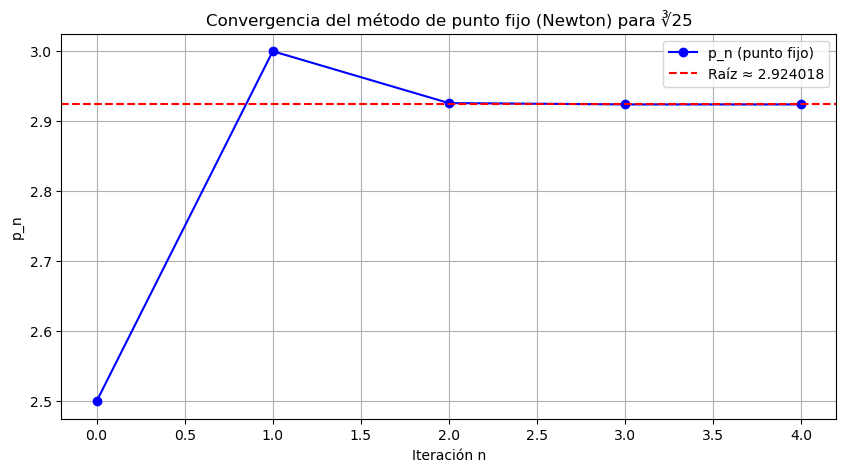

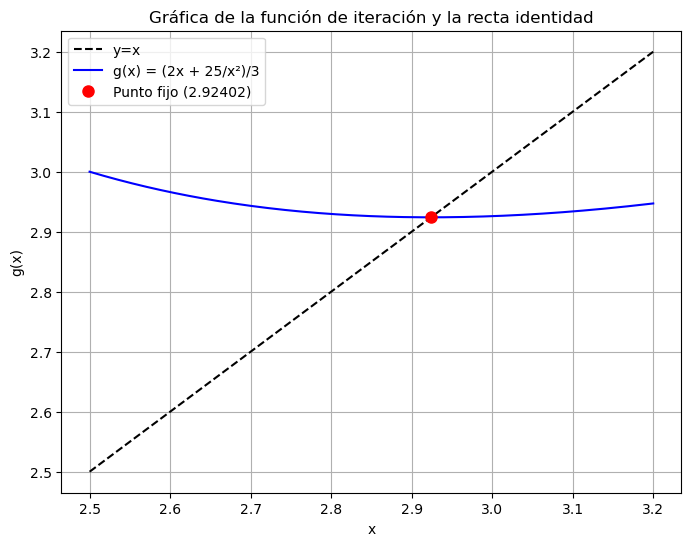

In [8]:
import math
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import bisect as sp_bisect
from src.root_finding import biseccion, punto_fijo   # nuestras implementaciones

# Definir la función g para la raíz cúbica (Newton)
def g_cubica(x):
    return (2*x + 25/(x*x)) / 3

# Parámetros
p0 = 2.5                # aproximación inicial (cualquier valor en [2,3] sirve)
tol = 1e-4
max_iter = 20

# Aplicar punto fijo
start = time.perf_counter()
raiz_pf, hist_pf, razon_pf = punto_fijo(g_cubica, p0, tol_abs=tol, rel_tol=None, max_iter=max_iter, verbose=True)
t_pf = time.perf_counter() - start

print("\n--- Resultado de punto fijo (Newton) ---")
print(f"Raíz: {raiz_pf:.10f}")
print(f"Razón: {razon_pf}")
print(f"Iteraciones: {len(hist_pf)-1}")
print(f"Tiempo: {t_pf*1e6:.2f} µs")

# Comparación con bisección (ejercicio 13 de la sección 2.1)
def f_cubica(x):
    return x**3 - 25

a, b = 2.9, 3.0
start = time.perf_counter()
raiz_bisec, hist_bisec, razon_bisec = biseccion(f_cubica, a, b, tol_abs=tol, verbose=False)
t_bisec = time.perf_counter() - start

print("\n--- Resultado de bisección (ejercicio 13, sección 2.1) ---")
print(f"Raíz: {raiz_bisec:.10f}")
print(f"Razón: {razon_bisec}")
print(f"Iteraciones: {len(hist_bisec)}")
print(f"Tiempo: {t_bisec*1e6:.2f} µs")

# Comparación de raíces
print("\n--- Comparación ---")
print(f"Diferencia entre métodos: {abs(raiz_pf - raiz_bisec):.2e}")
print(f"Reducción de iteraciones: {len(hist_bisec)} (bisección) vs {len(hist_pf)-1} (punto fijo)")
print(f"Relación de tiempos: {t_pf/t_bisec:.2f} (punto fijo más rápido si <1)")

# Gráfica de convergencia
iteraciones = [h[0] for h in hist_pf]
valores = [h[1] for h in hist_pf]

plt.figure(figsize=(10,5))
plt.plot(iteraciones, valores, 'bo-', label='p_n (punto fijo)')
plt.axhline(raiz_pf, color='r', linestyle='--', label=f'Raíz ≈ {raiz_pf:.6f}')
plt.xlabel('Iteración n')
plt.ylabel('p_n')
plt.title('Convergencia del método de punto fijo (Newton) para ∛25')
plt.legend()
plt.grid(True)
plt.show()

# Gráfica de g(x) y la recta y=x (para visualizar el punto fijo)
x_vals = np.linspace(2.5, 3.2, 200)
g_vals = [g_cubica(x) for x in x_vals]
plt.figure(figsize=(8,6))
plt.plot(x_vals, x_vals, 'k--', label='y=x')
plt.plot(x_vals, g_vals, 'b-', label='g(x) = (2x + 25/x²)/3')
plt.plot(raiz_pf, raiz_pf, 'ro', markersize=8, label=f'Punto fijo ({raiz_pf:.5f})')
plt.xlabel('x')
plt.ylabel('g(x)')
plt.title('Gráfica de la función de iteración y la recta identidad')
plt.legend()
plt.grid(True)
plt.show()

## Ejercicio 13 (sección 2.2)

Para cada ecuación, determinamos un intervalo $[a,b]$ donde la iteración de punto fijo $p_{n+1}=g(p_n)$ converge (es decir, $g$ es contractiva y mapea el intervalo en sí mismo). Luego implementamos la iteración hasta alcanzar una precisión de $10^{-5}$.

### a) $x = \dfrac{2 - e^x + x^2}{3}$

- $g(x)=\dfrac{2 - e^x + x^2}{3}$, $g'(x)=\dfrac{-e^x+2x}{3}$.
- En $[0,1]$: $|g'(x)|\le \max(|g'(0)|,|g'(1)|)=\max(1/3,\ 0.239)\approx0.333<1$.
- Además $g(0)=1/3\approx0.333$, $g(1)\approx0.094$, luego $g([0,1])\subset[0,1]$.
- **Intervalo:** $[0,1]$.

### b) $x = \dfrac{5}{x^2} + 2$

- $g(x)=\dfrac{5}{x^2}+2$, $g'(x)=-\dfrac{10}{x^3}$.
- Para $x\ge2.5$, $|g'(x)|=\dfrac{10}{x^3}\le\dfrac{10}{15.625}=0.64<1$.
- $g(2.5)=2.8$, $g(3)\approx2.5556$, luego $g([2.5,3])\subset[2.5556,2.8]\subset[2.5,3]$.
- **Intervalo:** $[2.5,3]$.

### c) $x = \sqrt{\dfrac{e^x}{3}}$

- Reescrita como $x = 2\ln x + \ln 3$ (aplicando logaritmo a $x^2=e^x/3$). Definimos $g(x)=2\ln x + \ln 3$.
- $g'(x)=\dfrac{2}{x}$. Para $x\ge3$, $|g'(x)|\le\dfrac{2}{3}<1$.
- $g(3)=2\ln3+\ln3=3\ln3\approx3.2958$, $g(4)=2\ln4+\ln3\approx2.7726+1.0986=3.8712$, ambos en $[3,4]$.
- **Intervalo:** $[3,4]$.

### d) $x = 5^{-x}$

- $g(x)=5^{-x}=e^{-x\ln5}$, $g'(x)=-\ln5\cdot5^{-x}$, $|g'(x)|=\ln5\cdot5^{-x}$.
- Para $x\ge0.4$, $\ln5\approx1.609$, $5^{-0.4}\approx0.525$, producto $\approx0.845<1$.
- Buscamos $[a,b]$ con $g([a,b])\subset[a,b]$. Tomamos $a=0.4$, $b=0.53$:
  - $g(0.4)=5^{-0.4}\approx0.525\le b$, $g(0.53)=5^{-0.53}\approx0.435\ge a$.
  - La imagen es $[0.435,0.525]\subset[0.4,0.53]$.
- **Intervalo:** $[0.4,0.53]$.

### e) $x = 6^{-x}$

- $g(x)=6^{-x}$, $|g'(x)|=\ln6\cdot6^{-x}$, $\ln6\approx1.7918$.
- Para $x\ge0.38$, $6^{-0.38}\approx0.506$, producto $\approx0.907<1$.
- Elegimos $a=0.38$, $b=0.53$:
  - $g(0.38)=6^{-0.38}\approx0.506$, $g(0.53)=6^{-0.53}\approx0.387$.
  - Imagen $[0.387,0.506]\subset[0.38,0.53]$.
- **Intervalo:** $[0.38,0.53]$.

### f) $x = 0.5(\sin x + \cos x)$

- $g(x)=0.5(\sin x+\cos x)$, $g'(x)=0.5(\cos x-\sin x)$.
- $|g'(x)|\le0.5\sqrt{2}\approx0.7071<1$ para todo $x$.
- En $[0.6,0.8]$: $g(0.6)\approx0.695$, $g(0.8)\approx0.707$, ambos en $[0.6,0.8]$.
- **Intervalo:** $[0.6,0.8]$.m

In [9]:
import math

def punto_fijo(g, p0, tol=1e-5, max_iter=100):
    """Iteración de punto fijo. Retorna (p, iteraciones, historia)."""
    p_old = p0
    historia = [p_old]
    for i in range(1, max_iter+1):
        p_new = g(p_old)
        historia.append(p_new)
        if abs(p_new - p_old) < tol:
            return p_new, i, historia
        p_old = p_new
    raise RuntimeError(f"No converge en {max_iter} iteraciones")

# Definir las funciones g
def g_a(x):
    return (2 - math.exp(x) + x*x) / 3

def g_b(x):
    return 5/(x*x) + 2

def g_c(x):
    return 2*math.log(x) + math.log(3)   # ln3 ≈ 1.098612

def g_d(x):
    return 5**(-x)

def g_e(x):
    return 6**(-x)

def g_f(x):
    return 0.5*(math.sin(x) + math.cos(x))

# Intervalos y puntos iniciales (tomamos el punto medio)
problemas = [
    ("a", g_a, 0.5),
    ("b", g_b, 2.75),
    ("c", g_c, 3.5),
    ("d", g_d, 0.465),
    ("e", g_e, 0.455),
    ("f", g_f, 0.7)
]

print("Ejercicio 13 - Iteración de punto fijo (tolerancia 1e-5)\n")
for nombre, g, p0 in problemas:
    try:
        raiz, iters, hist = punto_fijo(g, p0, tol=1e-5)
        print(f"{nombre}: raíz = {raiz:.8f}, iteraciones = {iters}")
        # Mostrar primeras y últimas iteraciones
        if len(hist) <= 6:
            print(f"   Historial: {hist}")
        else:
            print(f"   Historial: {hist[:3]} ... {hist[-3:]}")
    except Exception as e:
        print(f"{nombre}: Error - {e}")
    print()

Ejercicio 13 - Iteración de punto fijo (tolerancia 1e-5)

a: raíz = 0.25752908, iteraciones = 9
   Historial: [0.5, 0.20042624309995727, 0.27274906509837465] ... [0.2575124545148315, 0.2575349136152514, 0.257529084167956]

b: raíz = 2.69064482, iteraciones = 15
   Historial: [2.75, 2.6611570247933884, 2.70603950464874] ... [2.690637458143846, 2.690652576553981, 2.6906448152103803]

c: raíz = 3.73306751, iteraciones = 16
   Historial: [3.5, 3.604138225658846, 3.6627776734922586] ... [3.733038902251204, 3.733057530777044, 3.733067511106662]

d: raíz = 0.46962615, iteraciones = 25
   Historial: [0.465, 0.47312832395541704, 0.46697915325513584] ... [0.4696293268261945, 0.4696163269061205, 0.46962615258667045]

e: raíz = 0.44806703, iteraciones = 34
   Historial: [0.455, 0.4425284342091841, 0.45252850995705013] ... [0.4480692066643052, 0.4480581553645613, 0.44806702757334327]

f: raíz = 0.70481195, iteraciones = 4
   Historial: [0.7, 0.7045299372610898, 0.7047959184537735, 0.704811086412652

## Ejercicio 19 – Divergencia de la iteración de punto fijo cuando $|g'(p)|>1$

**Enunciado:**  
Sea $g \in C^1[a,b]$ y $p \in (a,b)$ con $g(p)=p$ y $|g'(p)|>1$.  
Demuestre que existe $\delta > 0$ tal que si $0 < |p_0-p| < \delta$, entonces $|p_0-p| < |p_1-p|$.  
Concluya que la iteración de punto fijo no converge a $p$ a menos que $p_0=p$.

### Demostración

1. **Continuidad de $g'$.**  
   Como $g'$ es continua en $[a,b]$ y $|g'(p)|>1$, existe un entorno de $p$ donde $|g'(x)|$ se mantiene mayor que $1$.  
   Sea $\lambda = |g'(p)| > 1$. Por continuidad, existe $\delta_1 > 0$ tal que para todo $x \in [p-\delta_1, p+\delta_1]$ se cumple $|g'(x)| > 1$.

2. **Teorema del valor medio.**  
   Para cualquier $p_0$ con $0 < |p_0-p| < \delta_1$, existe $\xi$ entre $p_0$ y $p$ tal que  
   \[
   g(p_0) - g(p) = g'(\xi)(p_0 - p).
   \]  
   Como $g(p)=p$, tenemos $p_1 - p = g'(\xi)(p_0 - p)$.

3. **Desigualdad estricta.**  
   Tomando valor absoluto:  
   \[
   |p_1 - p| = |g'(\xi)| \, |p_0 - p| > |p_0 - p|,
   \]  
   porque $|g'(\xi)| > 1$. Basta elegir $\delta = \delta_1$.

4. **No convergencia.**  
   Si $p_0 \neq p$, entonces $|p_1-p| > |p_0-p|$. Aplicando el mismo razonamiento a $p_1$ (si aún está en el intervalo), obtenemos $|p_2-p| > |p_1-p|$, y así sucesivamente. La sucesión $\{|p_n-p|\}$ es estrictamente creciente, por lo que no puede tender a $0$.  
   Por lo tanto, la única manera de converger a $p$ es partir exactamente de $p_0 = p$.

### Conclusión

La condición $|g'(p)|<1$ es necesaria para la convergencia local. Si la derivada supera $1$ en valor absoluto, cualquier error inicial se amplifica y la iteración diverge.

## Ejercicio 20 – Cálculo de la inversa $1/A$ por iteración de punto fijo

**Enunciado:**  
Sea $A>0$ constante y $g(x)=2x - Ax^2$.

### a) Demostrar que si la iteración converge a un límite no nulo, entonces el límite es $p=1/A$.

**Solución:**  
Supongamos que $\{x_n\}$ converge a $p \neq 0$ y que $x_{n+1}=g(x_n)$.  
Tomando límite en la recurrencia: $p = 2p - A p^2$.  
Restando $p$ a ambos lados: $0 = p - A p^2 = p(1 - A p)$.  
Como $p \neq 0$, se deduce $1 - A p = 0$, es decir, $p = 1/A$.

### b) Encontrar un intervalo alrededor de $1/A$ donde la iteración converge.

**Análisis de convergencia:**  
$g'(x) = 2 - 2A x$. En el punto fijo $p=1/A$, $g'(p)=2-2A\cdot(1/A)=0$.  
Esto sugiere convergencia cuadrática local.  

Para garantizar convergencia global, podemos buscar un intervalo $[c,d]$ tal que:
- $g([c,d]) \subset [c,d]$,  
- $|g'(x)| \le k < 1$ en ese intervalo.

Como $g'(x)=2-2Ax$, es lineal decreciente. La condición $|g'(x)|<1$ equivale a $-1 < 2-2Ax < 1$.  
Resolviendo:
- $2-2Ax < 1 \Rightarrow -2Ax < -1 \Rightarrow x > \frac{1}{2A}$.
- $2-2Ax > -1 \Rightarrow -2Ax > -3 \Rightarrow x < \frac{3}{2A}$.

Por lo tanto, en el intervalo $(\frac{1}{2A}, \frac{3}{2A})$ se tiene $|g'(x)|<1$.  
Además, $g$ es cóncava (segunda derivada $-2A<0$) y alcanza su máximo en $x=1/A$, con valor $g(1/A)=1/A$.  
Los extremos del intervalo:  
$g\left(\frac{1}{2A}\right)=2\cdot\frac{1}{2A} - A\left(\frac{1}{2A}\right)^2 = \frac{1}{A} - \frac{1}{4A} = \frac{3}{4A}$,
$g\left(\frac{3}{2A}\right)=2\cdot\frac{3}{2A} - A\left(\frac{3}{2A}\right)^2 = \frac{3}{A} - \frac{9}{4A} = \frac{3}{4A}$.

Así, $g$ mapea $[\frac{1}{2A}, \frac{3}{2A}]$ en $[\frac{3}{4A}, \frac{1}{A}]$, que está contenido en el intervalo original.  
Por tanto, para cualquier $x_0 \in (0, \frac{3}{2A})$ la iteración converge a $1/A$ (con convergencia cuadrática).

**Observación:** El intervalo máximo de convergencia es $(0, \frac{3}{2A})$, pues para $x_0 \ge \frac{3}{2A}$ la iteración se vuelve negativa o divergente.

Para A = 5.0, la inversa exacta es 0.2000000000
Iteración: 0.2000000000 (error 0.00e+00)
Número de iteraciones: 6


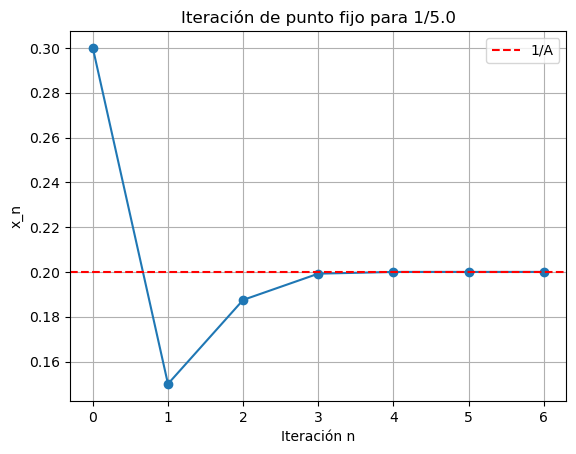

Con x0=0.35 (fuera del intervalo) se obtiene 0.200000 (no converge a 0.2)


In [10]:
import matplotlib.pyplot as plt

def invertir_por_punto_fijo(A, x0, tol=1e-10, max_iter=50):
    """Calcula 1/A mediante la iteración x_{n+1}=2x_n - A x_n^2."""
    x = x0
    historial = [x]
    for _ in range(max_iter):
        x_next = 2*x - A*x*x
        historial.append(x_next)
        if abs(x_next - x) < tol:
            break
        x = x_next
    return x_next, historial

# Parámetros
A = 5.0            # queremos 1/5 = 0.2
x0 = 0.3           # dentro del intervalo (0, 3/(2A)=0.3)

raiz, hist = invertir_por_punto_fijo(A, x0)

print(f"Para A = {A}, la inversa exacta es {1/A:.10f}")
print(f"Iteración: {raiz:.10f} (error {abs(raiz-1/A):.2e})")
print(f"Número de iteraciones: {len(hist)-1}")

# Gráfica de convergencia
plt.plot(hist, 'o-')
plt.axhline(1/A, color='r', linestyle='--', label='1/A')
plt.xlabel('Iteración n')
plt.ylabel('x_n')
plt.title(f'Iteración de punto fijo para 1/{A}')
plt.legend()
plt.grid(True)
plt.show()

# Verificar el intervalo de convergencia (prueba con x0 fuera del intervalo)
x0_malo = 0.35   # > 3/(2A) = 0.3
raiz_mala, hist_mala = invertir_por_punto_fijo(A, x0_malo)
print(f"Con x0={x0_malo} (fuera del intervalo) se obtiene {raiz_mala:.6f} (no converge a 0.2)")

## Problema 23 – Iteración para calcular $\sqrt{2}$

**Enunciado:**  
a) Use el teorema 2.4 para mostrar que la sucesión definida por

$$x_n = \frac{1}{2}x_{n-1} + \frac{1}{x_{n-1}}, \quad n\ge 1,$$

converge a $\sqrt{2}$ siempre que $x_0 > \sqrt{2}$.

b) Use el hecho de que $0 < (x_0 - \sqrt{2})^2$ siempre que $x_0 \neq \sqrt{2}$ para mostrar que si $0 < x_0 < \sqrt{2}$, entonces $x_1 > \sqrt{2}$.

c) Use los resultados de las partes a) y b) para mostrar que la sucesión converge a $\sqrt{2}$ siempre que $x_0 > 0$.

### Solución teórica

#### a) Convergencia para $x_0 > \sqrt{2}$

La función de iteración es $g(x) = \dfrac{x}{2} + \dfrac{1}{x}$. Derivamos:

$$g'(x) = \frac{1}{2} - \frac{1}{x^2}.$$

Para $x > \sqrt{2}$, tenemos $x^2 > 2$, luego $\frac{1}{x^2} < \frac{1}{2}$, por lo que $g'(x) > 0$. Además, $g'(x) < \frac{1}{2}$ (pues $\frac{1}{x^2}>0$). En particular, $0 < g'(x) < \frac{1}{2} = k < 1$.

Ahora vemos que $g$ mapea $(\sqrt{2}, \infty)$ en $(\sqrt{2}, \infty)$. Para $x > \sqrt{2}$,

$$g(x) - \sqrt{2} = \frac{x}{2} + \frac{1}{x} - \sqrt{2} = \frac{x^2 + 2 - 2\sqrt{2}x}{2x} = \frac{(x - \sqrt{2})^2}{2x} > 0.$$

Luego $g(x) > \sqrt{2}$. También $x - g(x) = x - \frac{x}{2} - \frac{1}{x} = \frac{x}{2} - \frac{1}{x} = \frac{x^2-2}{2x} > 0$, así $g(x) < x$. Por tanto, $g$ mapea el intervalo $[\sqrt{2}+\varepsilon, M]$ en sí mismo y es contractiva. El teorema de punto fijo (2.4) garantiza convergencia a la única raíz $\sqrt{2}$.

#### b) Si $0 < x_0 < \sqrt{2}$, entonces $x_1 > \sqrt{2}$

Calculamos $x_1 = \frac{x_0}{2} + \frac{1}{x_0}$. Entonces

$$x_1 - \sqrt{2} = \frac{x_0}{2} + \frac{1}{x_0} - \sqrt{2} = \frac{x_0^2 + 2 - 2\sqrt{2}x_0}{2x_0} = \frac{(x_0 - \sqrt{2})^2}{2x_0} > 0,$$

ya que $(x_0 - \sqrt{2})^2 > 0$ (pues $x_0 \neq \sqrt{2}$) y $x_0 > 0$. Así $x_1 > \sqrt{2}$.

#### c) Convergencia para cualquier $x_0 > 0$

- Si $x_0 = \sqrt{2}$, la sucesión es constante (trivial).
- Si $x_0 > \sqrt{2}$, por (a) converge a $\sqrt{2}$.
- Si $0 < x_0 < \sqrt{2}$, por (b) obtenemos $x_1 > \sqrt{2}$, y a partir de ahí aplicamos (a) a la subsucesión $\{x_n\}_{n\ge 1}$.

Por lo tanto, para todo $x_0 > 0$, la iteración converge a $\sqrt{2}$.

**Observación:** Este es el **método de Herón** (o babilónico) para calcular raíces cuadradas. Converge cuadráticamente.

=== Método de Herón para sqrt(2) ===

x0 = 2.00  ->  raíz = 1.4142135624, iteraciones = 5
x0 = 1.50  ->  raíz = 1.4142135624, iteraciones = 4
x0 = 1.00  ->  raíz = 1.4142135624, iteraciones = 5
x0 = 0.50  ->  raíz = 1.4142135624, iteraciones = 7
x0 = 0.10  ->  raíz = 1.4142135624, iteraciones = 9


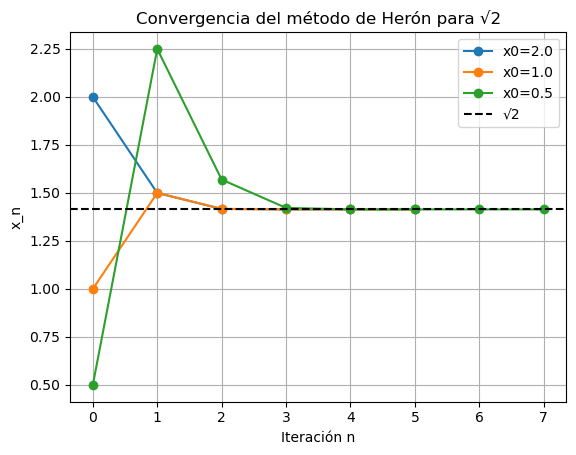

In [12]:
import matplotlib.pyplot as plt

def heron(A, x0, tol=1e-10, max_iter=50):
    """
    Método de Herón para calcular sqrt(A).
    Iteración: x_{n+1} = 0.5*(x_n + A/x_n)
    """
    x = x0
    historial = [x]
    for _ in range(max_iter):
        x_next = 0.5 * (x + A/x)
        historial.append(x_next)
        if abs(x_next - x) < tol:
            break
        x = x_next
    return x_next, historial

# Parámetros
A = 2.0  # sqrt(2) ≈ 1.4142135623730951
print("=== Método de Herón para sqrt(2) ===\n")
for x0 in [2.0, 1.5, 1.0, 0.5, 0.1]:
    raiz, hist = heron(A, x0)
    print(f"x0 = {x0:4.2f}  ->  raíz = {raiz:.10f}, iteraciones = {len(hist)-1}")
    # Graficamos los primeros tres casos para visualizar
    if x0 in [2.0, 1.0, 0.5]:
        plt.plot(hist, 'o-', label=f'x0={x0}')

# Línea horizontal del valor exacto
plt.axhline(A**0.5, color='k', linestyle='--', label='√2')
plt.xlabel('Iteración n')
plt.ylabel('x_n')
plt.title('Convergencia del método de Herón para √2')
plt.legend()
plt.grid(True)
plt.show()

# Caso con x0 negativo (problema 24b)
print("\n=== Caso x0 < 0 (Problema 24b) ===")
x0_neg = -1.0
raiz_neg, hist_neg = heron(A, x0_neg)
print(f"x0 = {x0_neg}  ->  raíz = {raiz_neg:.10f}")
print(f"¿Converge a -√2? {raiz_neg + A**0.5:.2e} (diferencia con -√2)")

# También mostramos el historial para x0 negativo
plt.figure()
plt.plot(hist_neg, 's-', color='red', label=f'x0={x0_neg}')
plt.axhline(-A**0.5, color='k', linestyle='--', label='-√2')
plt.xlabel('Iteración n')
plt.ylabel('x_n')
plt.title('Convergencia con x0 negativo')
plt.legend()
plt.grid(True)
plt.show()